Wrote 211 excitation evolution rows:
/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/excitation_evolved_master.csv
/home/pnichols/MDsims/excitation_evolved_master.csv


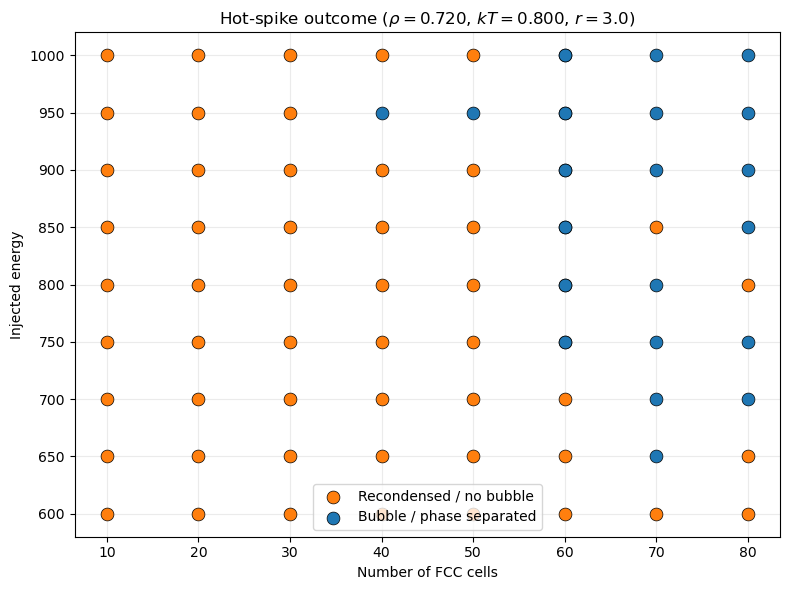

In [1]:
densities = [0.720]
temperatures = [0.800]
energies = [600, 650, 700, 750, 800, 850, 900, 950, 1000]

radii = [3.0]
n_cells = [10, 20, 30, 40, 50, 60, 70, 80]


import matplotlib.pyplot as plt
from md_Helpers import master_csv

# Reads existing run metadata; it does not rerun the simulations.
df = master_csv.build_excitation_evolved_master_csv(include_legacy=False)

sweep = df[
    df["n_fcc_cells"].isin(n_cells)
    & df["energy_deposition"].isin(energies)
    & df["density"].isin(densities)
    & df["temp"].isin(temperatures)
    & df["radius"].isin(radii)
    & (df["excitation_method"] == "velocity_rescale_com")
    & (df["ensemble"].str.upper() == "NVE")
].copy()

colors = {
    "phase_separated": "tab:blue",
    "not_phase_separated": "tab:orange",
}

labels = {
    "phase_separated": "Bubble / phase separated",
    "not_phase_separated": "Recondensed / no bubble",
}

fig, ax = plt.subplots(figsize=(8, 6))

for phase, group in sweep.groupby("voxel_phase"):
    ax.scatter(
        group["n_fcc_cells"],
        group["energy_deposition"],
        s=85,
        color=colors.get(phase, "gray"),
        label=labels.get(phase, phase),
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )

ax.set(
    xlabel="Number of FCC cells",
    ylabel="Injected energy",
    title=r"Hot-spike outcome ($\rho=0.720$, $kT=0.800$, $r=3.0$)",
)

ax.set_xticks(n_cells)
ax.set_yticks(energies)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()